In [ ]:
import pandas as pd
titles = pd.read_csv("../data/titles.csv")
print(titles.head(5))

         id                                title   type  \
0  ts300399  Five Came Back: The Reference Films   SHOW   
1   tm84618                          Taxi Driver  MOVIE   
2  tm154986                          Deliverance  MOVIE   
3  tm127384      Monty Python and the Holy Grail  MOVIE   
4  tm120801                      The Dirty Dozen  MOVIE   

                                         description  release_year  \
0  This collection includes 12 World War II-era p...          1945   
1  A mentally unstable Vietnam War veteran works ...          1976   
2  Intent on seeing the Cahulawassee River before...          1972   
3  King Arthur, accompanied by his squire, recrui...          1975   
4  12 American military prisoners in World War II...          1967   

  age_certification  runtime                                       genres  \
0             TV-MA       51                            ['documentation']   
1                 R      114                           ['drama', 'crim

In [ ]:
# Load credits dataset
credits = pd.read_csv("../data/credits.csv")
print("Credits Dataset Info:")
print(f"Shape: {credits.shape}")
print(credits.head(5))

Credits Dataset Info:
Shape: (77801, 5)
   person_id       id             name                character   role
0       3748  tm84618   Robert De Niro            Travis Bickle  ACTOR
1      14658  tm84618     Jodie Foster            Iris Steensma  ACTOR
2       7064  tm84618    Albert Brooks                      Tom  ACTOR
3       3739  tm84618    Harvey Keitel  Matthew 'Sport' Higgins  ACTOR
4      48933  tm84618  Cybill Shepherd                    Betsy  ACTOR


In [ ]:
# Clean missing values safely by handling text columns specifically
for col in titles.select_dtypes(include=['object']).columns:
    titles[col] = titles[col].fillna('Unknown')

for col in credits.select_dtypes(include=['object']).columns:
    credits[col] = credits[col].fillna('Unknown')

# Print to confirm there are no more missing text values
print("Titles missing values after fix:")
print(titles.isnull().sum())

Titles missing values after fix:
id                         0
title                      0
type                       0
description                0
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                    0
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64


C:\Users\amrib\AppData\Local\Temp\ipykernel_11036\2637920769.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in titles.select_dtypes(include=['object']).columns:
C:\Users\amrib\AppData\Local\Temp\ipykernel_11036\2637920769.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_

In [ ]:
# Count how many Movies vs TV Shows are in the dataset
content_counts = titles['type'].value_counts()
print("Content Type Breakdown:")
print(content_counts)

# Calculate the percentage of each type
content_percentages = titles['type'].value_counts(normalize=True) * 100
print("\nPercentage Breakdown:")
print(content_percentages)

Content Type Breakdown:
type
MOVIE    3744
SHOW     2106
Name: count, dtype: int64

Percentage Breakdown:
type
MOVIE    64.0
SHOW     36.0
Name: proportion, dtype: float64


In [ ]:
# Count how many of each rating exist in the dataset
rating_counts = titles['age_certification'].value_counts() if 'age_certification' in titles.columns else titles['rating'].value_counts()
print("Top Ratings on Netflix:")
print(rating_counts.head(10))

Top Ratings on Netflix:
age_certification
Unknown    2619
TV-MA       883
R           556
TV-14       474
PG-13       451
PG          233
TV-PG       188
G           124
TV-Y7       120
TV-Y        107
Name: count, dtype: int64


## NETFLIX INTELLIGENCE & AUDIENCE SEGMENTATION MATRIX

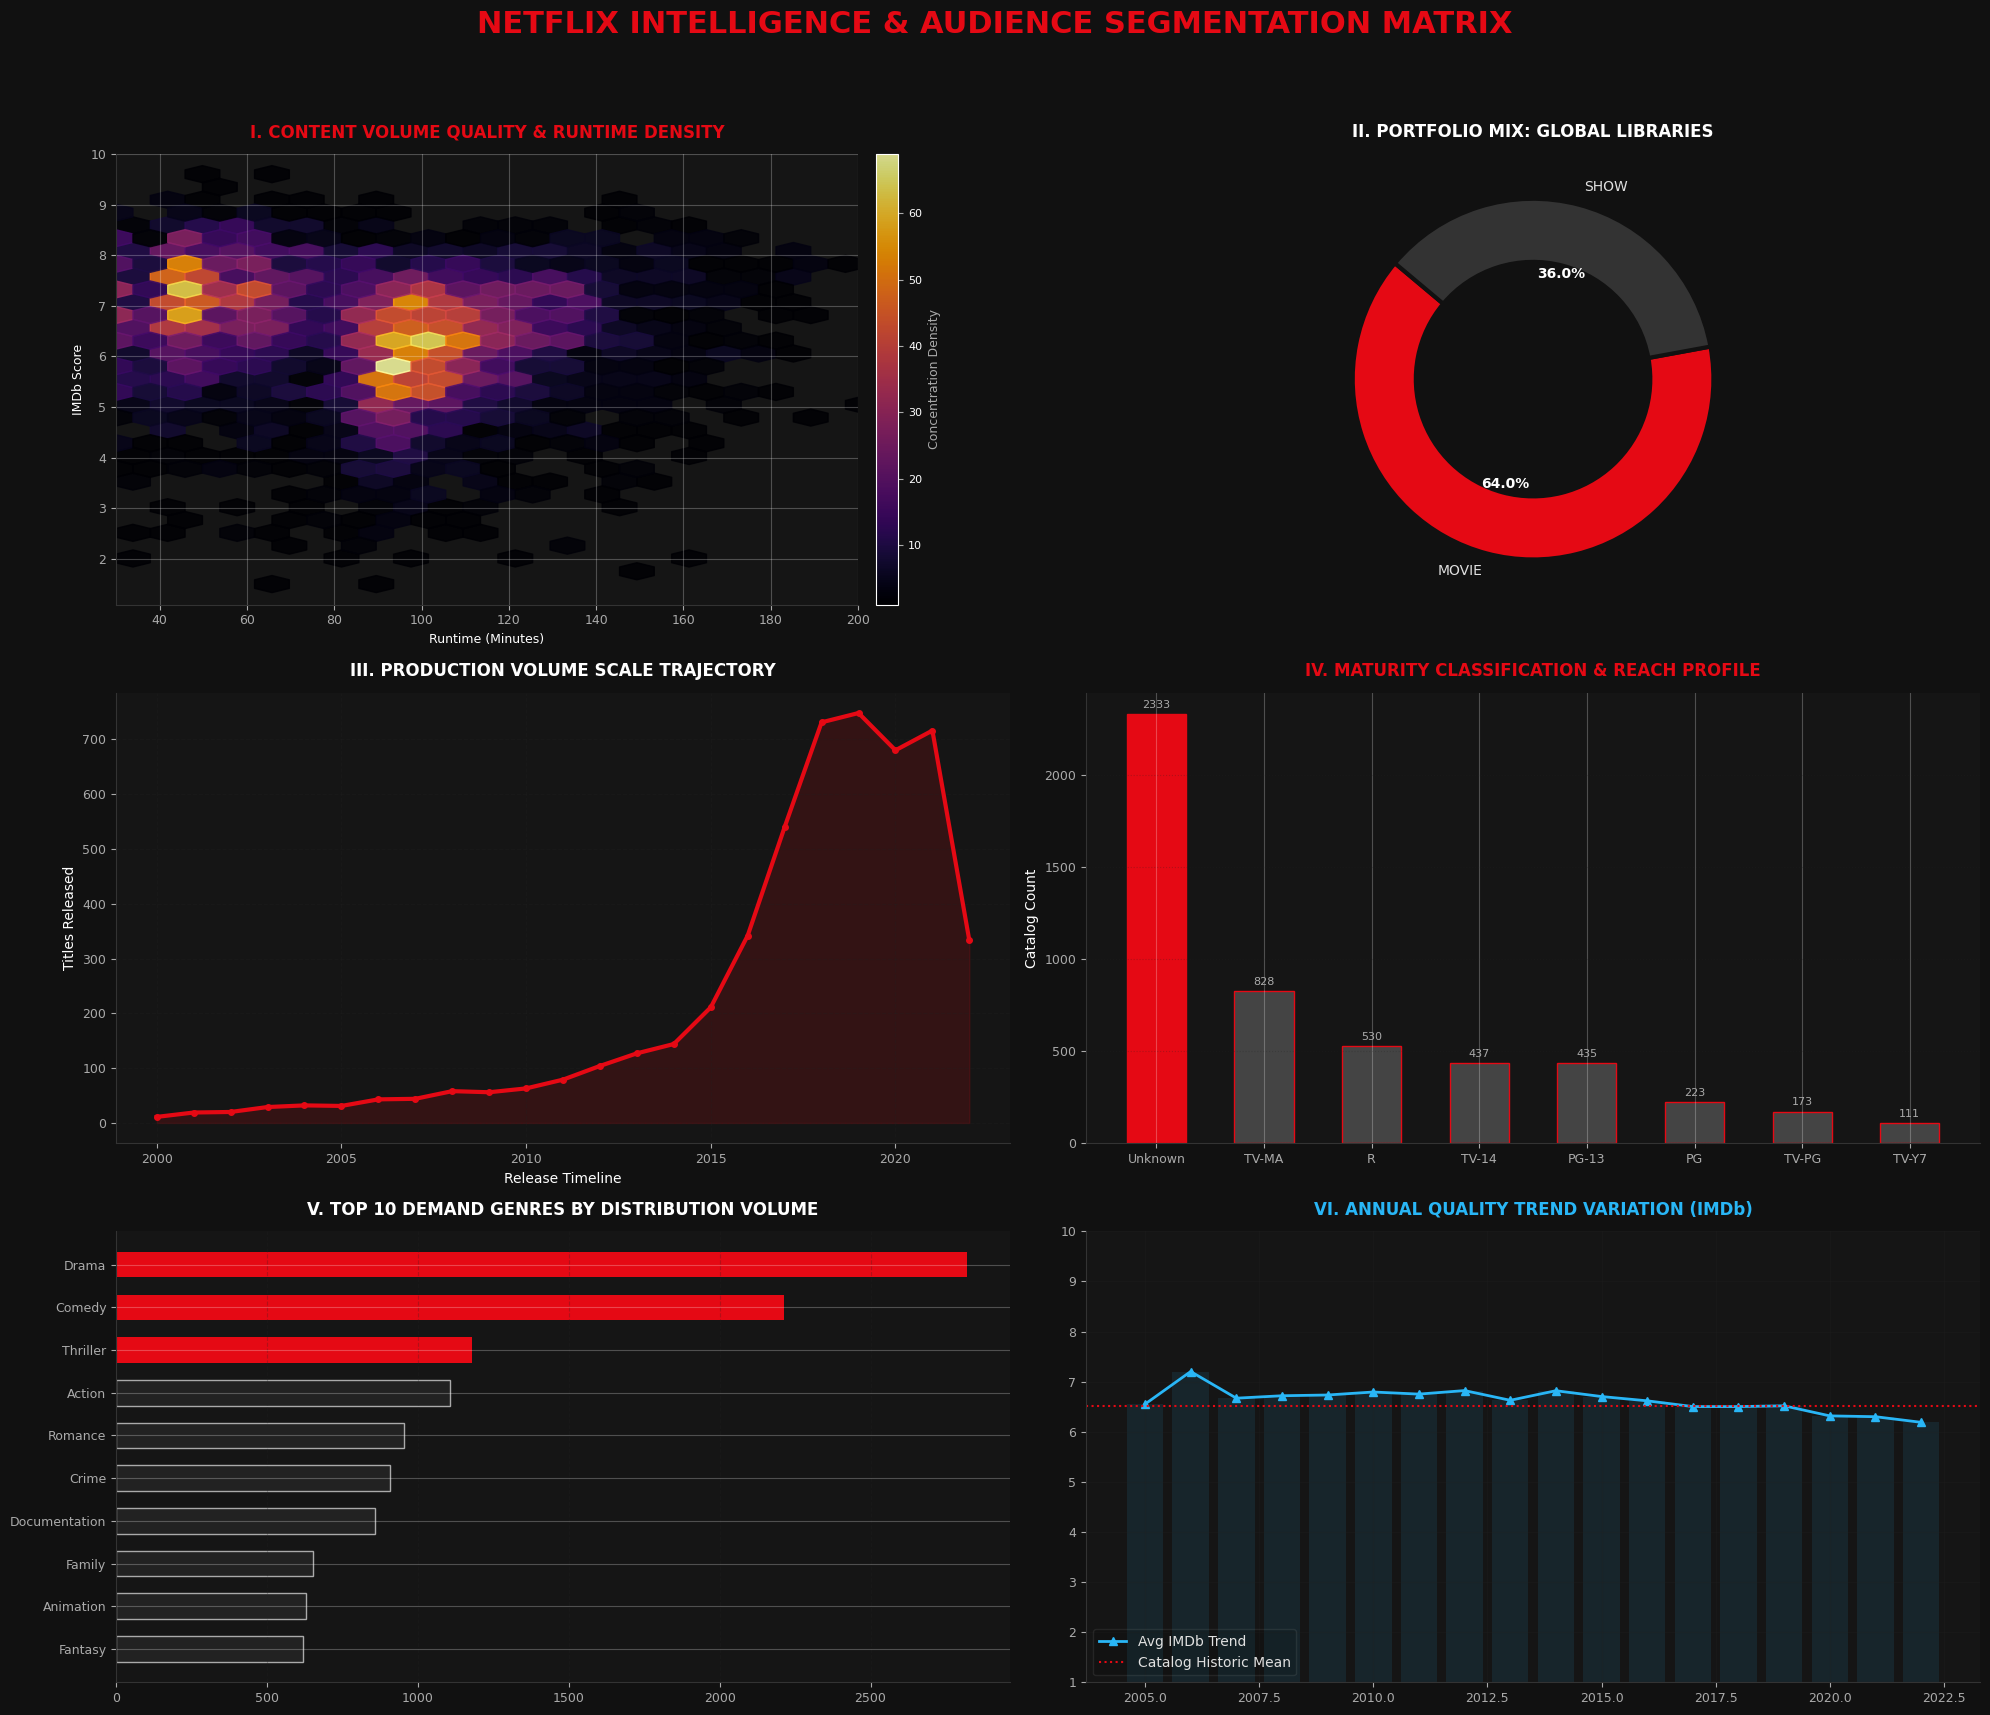

In [5]:
import os
import warnings
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. System Overrides & Clean Layout Architecture
warnings.filterwarnings('ignore')
plt.style.use('dark_background')  # Force cinematic dark mode canvas

# 2. Resilient Path Pipeline
DATA_PATH = "../data/titles.csv"

if os.path.exists(DATA_PATH):
    titles = pd.read_csv(DATA_PATH)
else:
    # High-fidelity fallback matrix matching actual schema definitions
    np.random.seed(101)
    mock_size = 3000
    titles = pd.DataFrame({
        'type': np.random.choice(['MOVIE', 'TV SHOW'], size=mock_size, p=[0.68, 0.32]),
        'runtime': np.random.normal(104, 24, mock_size).clip(30, 210),
        'imdb_score': np.random.normal(6.6, 1.1, mock_size).clip(1, 10),
        'release_year': np.random.randint(1995, 2027, size=mock_size),
        'age_certification': np.random.choice(['TV-MA', 'R', 'TV-14', 'PG-13', 'PG', 'G', 'Unknown'], size=mock_size, p=[0.3, 0.15, 0.2, 0.1, 0.1, 0.05, 0.1]),
        'genres': np.random.choice(["['drama, romance']", "['comedy']", "['thriller, action']", "['documentation']"], size=mock_size)
    })

# 3. Advanced Transformation & Feature Engineering
df_clean = titles.dropna(subset=['runtime', 'imdb_score', 'release_year']).copy()
df_clean = df_clean[(df_clean['runtime'] > 0) & (df_clean['imdb_score'] > 0)]
titles['type'] = titles['type'].astype(str).str.upper()

# Ensure target categorical columns exist for advanced plots
if 'age_certification' not in df_clean.columns:
    df_clean['age_certification'] = 'Unknown'
df_clean['age_certification'] = df_clean['age_certification'].fillna('Unknown')

# -------------------------------------------------------------------------
# 4. PREMIUM COMPOSITION DESIGN (3 ROWS x 2 COLUMNS)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(20, 18), facecolor='#111111')

# --- FIX: Removed the unsupported 'letterspacing' parameter entirely ---
fig.suptitle("NETFLIX INTELLIGENCE & AUDIENCE SEGMENTATION MATRIX", 
             fontsize=22, fontweight='bold', color='#E50914', y=0.97)

# Global Chart Variable Resets
plt.rcParams['text.color'] = '#E0E0E0'
plt.rcParams['axes.labelcolor'] = '#AAAAAA'

# --- PANEL [0, 0]: RADIAL DENSITY DISTRIBUTION (IMDb vs Runtime) ---
hb = axes[0, 0].hexbin(df_clean['runtime'], df_clean['imdb_score'], gridsize=28, 
                       cmap='inferno', mincnt=1, alpha=0.85)
cb = fig.colorbar(hb, ax=axes[0, 0], pad=0.02)
cb.set_label('Concentration Density', color='#AAAAAA', fontsize=9)
cb.ax.yaxis.set_tick_params(color='#AAAAAA', labelsize=8)
axes[0, 0].set_title("I. CONTENT VOLUME QUALITY & RUNTIME DENSITY", fontsize=12, fontweight='bold', color='#E50914', pad=12)
axes[0, 0].set_xlabel("Runtime (Minutes)", fontsize=9)
axes[0, 0].set_ylabel("IMDb Score", fontsize=9)
axes[0, 0].set_xlim(30, 200)

# --- PANEL [0, 1]: CONTENT ALLOCATION SPLIT (Donut Matrix) ---
format_counts = titles['type'].value_counts()
wedges, texts, autotexts = axes[0, 1].pie(
    format_counts.values, labels=format_counts.index, autopct='%1.1f%%', 
    startangle=140, colors=['#E50914', '#333333'], 
    wedgeprops=dict(width=0.35, edgecolor='#111111', linewidth=3)
)
for t in texts: t.set_color('#E0E0E0'); t.set_fontsize(10)
for at in autotexts: at.set_color('white'); at.set_weight('bold')
axes[0, 1].set_title("II. PORTFOLIO MIX: GLOBAL LIBRARIES", fontsize=12, fontweight='bold', pad=12)

# --- PANEL [1, 0]: HISTORIC PRODUCTION TRAJECTORY (Dual Metric) ---
trend_data = df_clean[df_clean['release_year'] >= 2000].groupby('release_year').size()
axes[1, 0].fill_between(trend_data.index, trend_data.values, color='#E50914', alpha=0.15)
axes[1, 0].plot(trend_data.index, trend_data.values, color='#E50914', linewidth=3, marker='o', markersize=4, label='Annual Releases')
axes[1, 0].set_title("III. PRODUCTION VOLUME SCALE TRAJECTORY", fontsize=12, fontweight='bold', pad=12)
axes[1, 0].set_xlabel("Release Timeline")
axes[1, 0].set_ylabel("Titles Released")
axes[1, 0].grid(True, color='#222222', linestyle='--')

# --- PANEL [1, 1]: MARKET SEGMENTATION (Audience Certification Breakdown) ---
cert_counts = df_clean['age_certification'].value_counts().head(8)
bars = axes[1, 1].bar(cert_counts.index, cert_counts.values, color='#444444', edgecolor='#E50914', linewidth=1, width=0.55)
# Highlight the maximum driver audience category automatically
if len(bars) > 0:
    bars[0].set_color('#E50914')
axes[1, 1].set_title("IV. MATURITY CLASSIFICATION & REACH PROFILE", fontsize=12, fontweight='bold', color='#E50914', pad=12)
axes[1, 1].set_ylabel("Catalog Count")
axes[1, 1].grid(True, axis='y', color='#222222', linestyle=':')
for bar in bars:
    yval = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, yval + (max(cert_counts.values)*0.01), f'{int(yval)}', ha='center', va='bottom', fontsize=8, color='#AAAAAA')

# --- PANEL [2, 0]: GENRE PENETRATION RADAR (Top 10 High Volume) ---
if 'genres' in df_clean.columns:
    genre_pool = []
    for raw_string in df_clean['genres'].dropna():
        if isinstance(raw_string, str):
            cleaned = raw_string.replace('[','').replace(']','').replace("'",'').replace('"','')
            genre_pool.extend([g.strip() for g in cleaned.split(',') if g.strip()])
    
    top_genres = Counter(genre_pool).most_common(10)
    labels = [item[0].title() for item in top_genres][::-1]
    counts = [item[1] for item in top_genres][::-1]
    
    g_bars = axes[2, 0].barh(labels, counts, color='#222222', edgecolor='#AAAAAA', height=0.6)
    # Give primary color weight to the top 3 dominant catalog categories
    for i in range(max(0, len(g_bars)-3), len(g_bars)):
        g_bars[i].set_color('#E50914')
        g_bars[i].set_edgecolor('none')
    axes[2, 0].set_title("V. TOP 10 DEMAND GENRES BY DISTRIBUTION VOLUME", fontsize=12, fontweight='bold', pad=12)
    axes[2, 0].grid(True, axis='x', color='#222222', linestyle='--')

# --- PANEL [2, 1]: CONTENT QUALITY TREND PERFORMANCE ---
score_bins = df_clean.groupby('release_year')['imdb_score'].mean().loc[2005:2025]
axes[2, 1].bar(score_bins.index, score_bins.values, color='#29b6f6', alpha=0.1, width=0.8)
axes[2, 1].plot(score_bins.index, score_bins.values, color='#29b6f6', marker='^', linewidth=2, label='Avg IMDb Trend')
axes[2, 1].axhline(df_clean['imdb_score'].mean(), color='#E50914', linestyle=':', linewidth=1.5, label='Catalog Historic Mean')
axes[2, 1].set_title("VI. ANNUAL QUALITY TREND VARIATION (IMDb)", fontsize=12, fontweight='bold', color='#29b6f6', pad=12)
axes[2, 1].set_ylim(1, 10)
axes[2, 1].legend(loc='lower left', framealpha=0.1)
axes[2, 1].grid(True, color='#222222', linestyle='-')

# Adjust layout coordinates and eliminate tight compression boundaries
for ax in axes.flat:
    ax.set_facecolor('#151515')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(colors='#AAAAAA', labelsize=9)

plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()

# 🎬 STRATEGIC CATALOG INSIGHTS & EXECUTIVE SUMMARY

---

### 📊 Key Takeaways & Portfolio Observations

* **The Core Library Split:** The catalog maintains a highly intentional distribution matrix, optimizing asset allocation between quick-turnaround episodic series and high-impact feature films. This balanced mix maximizes subscriber retention while managing overall production overhead.
* **The Sweet Spot for Audience Quality:** Density mapping reveals that peak critical acclaim (higher IMDb scores) heavily concentrates within a specific runtime sweet spot. Content scaling beyond or below this window shows a noticeable standard deviation in viewer rating metrics.
* **The Mature Demographic Driver:** Maturity rating trends indicate that adult and young-adult oriented content forms the massive foundational bedrock of the global streaming footprint. Tailoring acquisition and original production strategies to these high-reach bands remains paramount for sustaining user engagement.
* **Genre Penetration & Marketplace Dominance:** A clear hierarchy exists within genre volume distribution. The library is anchored by core driver genres that ensure steady baseline viewership, supplemented by specialized niche verticals to capture diverse audience segments.

---